In [49]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('/Users/andreyfeduhin/Urbanomy-data/data/leningrad_oblast/ gatchina/blocks_agg.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,count_supermarket,capacity_park,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,0.0,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [2]:
import blocksnet.analysis.network

# Вычисления **площади участка**

In [50]:
baseline_blocks_test = basline_blocks.copy().to_crs(3857)
basline_blocks["site_area"] = baseline_blocks_test.geometry.area
basline_blocks.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,capacity_park,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry,site_area
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",836277.821580
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",420144.041613
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",302985.560227
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",124546.982903
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",119574.990985


# Вычисления **связанности**

In [51]:
import blocksnet
import pkgutil

[mod.name for mod in pkgutil.iter_modules(blocksnet.analysis.__path__)]


['centrality',
 'diversity',
 'geometry',
 'indicators',
 'land_use',
 'morphotypes',
 'network',
 'provision',
 'services',
 'vacant_area']

In [52]:
from blocksnet.analysis.network  import area_accessibility
matrix = pd.read_pickle('/Users/andreyfeduhin/Urbanomy-data/data/leningrad_oblast/ gatchina/matrix.pickle')

In [53]:
# переиндексируем матрицу, индекс == столбцы == 0..n-1
matrix = matrix.copy()
matrix.index = range(len(matrix))
matrix.columns = matrix.index

# приводим блоки к тем же меткам
basline_blocks = basline_blocks.reset_index(drop=True)

# проверяем, что размеры совпадают
assert len(matrix) == len(basline_blocks)

area_acc_df = area_accessibility(matrix, basline_blocks)
basline_blocks = basline_blocks.join(area_acc_df)
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry,site_area,area_accessibility
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",836277.821580,10.063987
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",420144.041613,10.210398
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",302985.560227,8.669212
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",124546.982903,7.467434
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",119574.990985,8.285434


# Вычисления **показателей застройки**

In [54]:
from blocksnet.analysis.indicators import calculate_density_indicators 

blocks_df = calculate_density_indicators(basline_blocks[[
    'site_area',
    'footprint_area',
    'build_floor_area',
    'living_area'
]])
blocks_df.head()

2026-03-12 13:21:58.453 | WARNING  | blocksnet.analysis.indicators.density.schemas:_before_validate:19 - The non_living_area is not in columns, restoring


,site_area,footprint_area,build_floor_area,living_area,non_living_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,836277.821580,7383.849525,10126.647386,930.718518,9195.928868,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411
1,420144.041613,15304.958732,89136.104333,63508.757346,25627.346987,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447
2,302985.560227,17141.628200,91971.715857,72292.449720,19679.266138,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039
3,124546.982903,9453.530183,21635.756605,4286.353971,17349.402634,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230
4,119574.990985,8567.309559,18736.950831,1791.211457,16945.739375,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953


In [55]:
basline_blocks.loc[:, blocks_df.columns] = blocks_df
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,geometry,site_area,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",836277.821580,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",420144.041613,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",302985.560227,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",124546.982903,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",119574.990985,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953


# Вычисления **морфотипов застройки**

In [56]:
from blocksnet.analysis.morphotypes import get_strelka_morphotypes


blocks_df = get_strelka_morphotypes(basline_blocks)
basline_blocks.loc[:, blocks_df.columns] = blocks_df
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,site_area,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,836277.821580,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411,individual residential
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,420144.041613,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447,mid-rise
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,302985.560227,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039,mid-rise
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,124546.982903,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230,low-rise model
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,119574.990985,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953,low-rise model


# Выбор **проктной территории**

# Финальный набор данных

In [57]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]


In [58]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('/Users/andreyfeduhin/Downloads/Urbanomy/examples/land_value_modeling/catboost_model.cbm')  # модель на лог-цене
print(len(model.feature_names_))

121


In [59]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

In [60]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [63]:
blocks_clean = basline_blocks

In [64]:
blocks_clean["id"] = blocks_clean.index

In [19]:
# blocks_clean.to_file('./data/test/gatchina_baseline.geojson', driver='GeoJSON')

/var/folders/yl/0swqblhn58d982w93b_6pg1w0000gn/T/ipykernel_24151/1807181840.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_clean.loc[blocks_clean["id"]==87].centroid.plot(


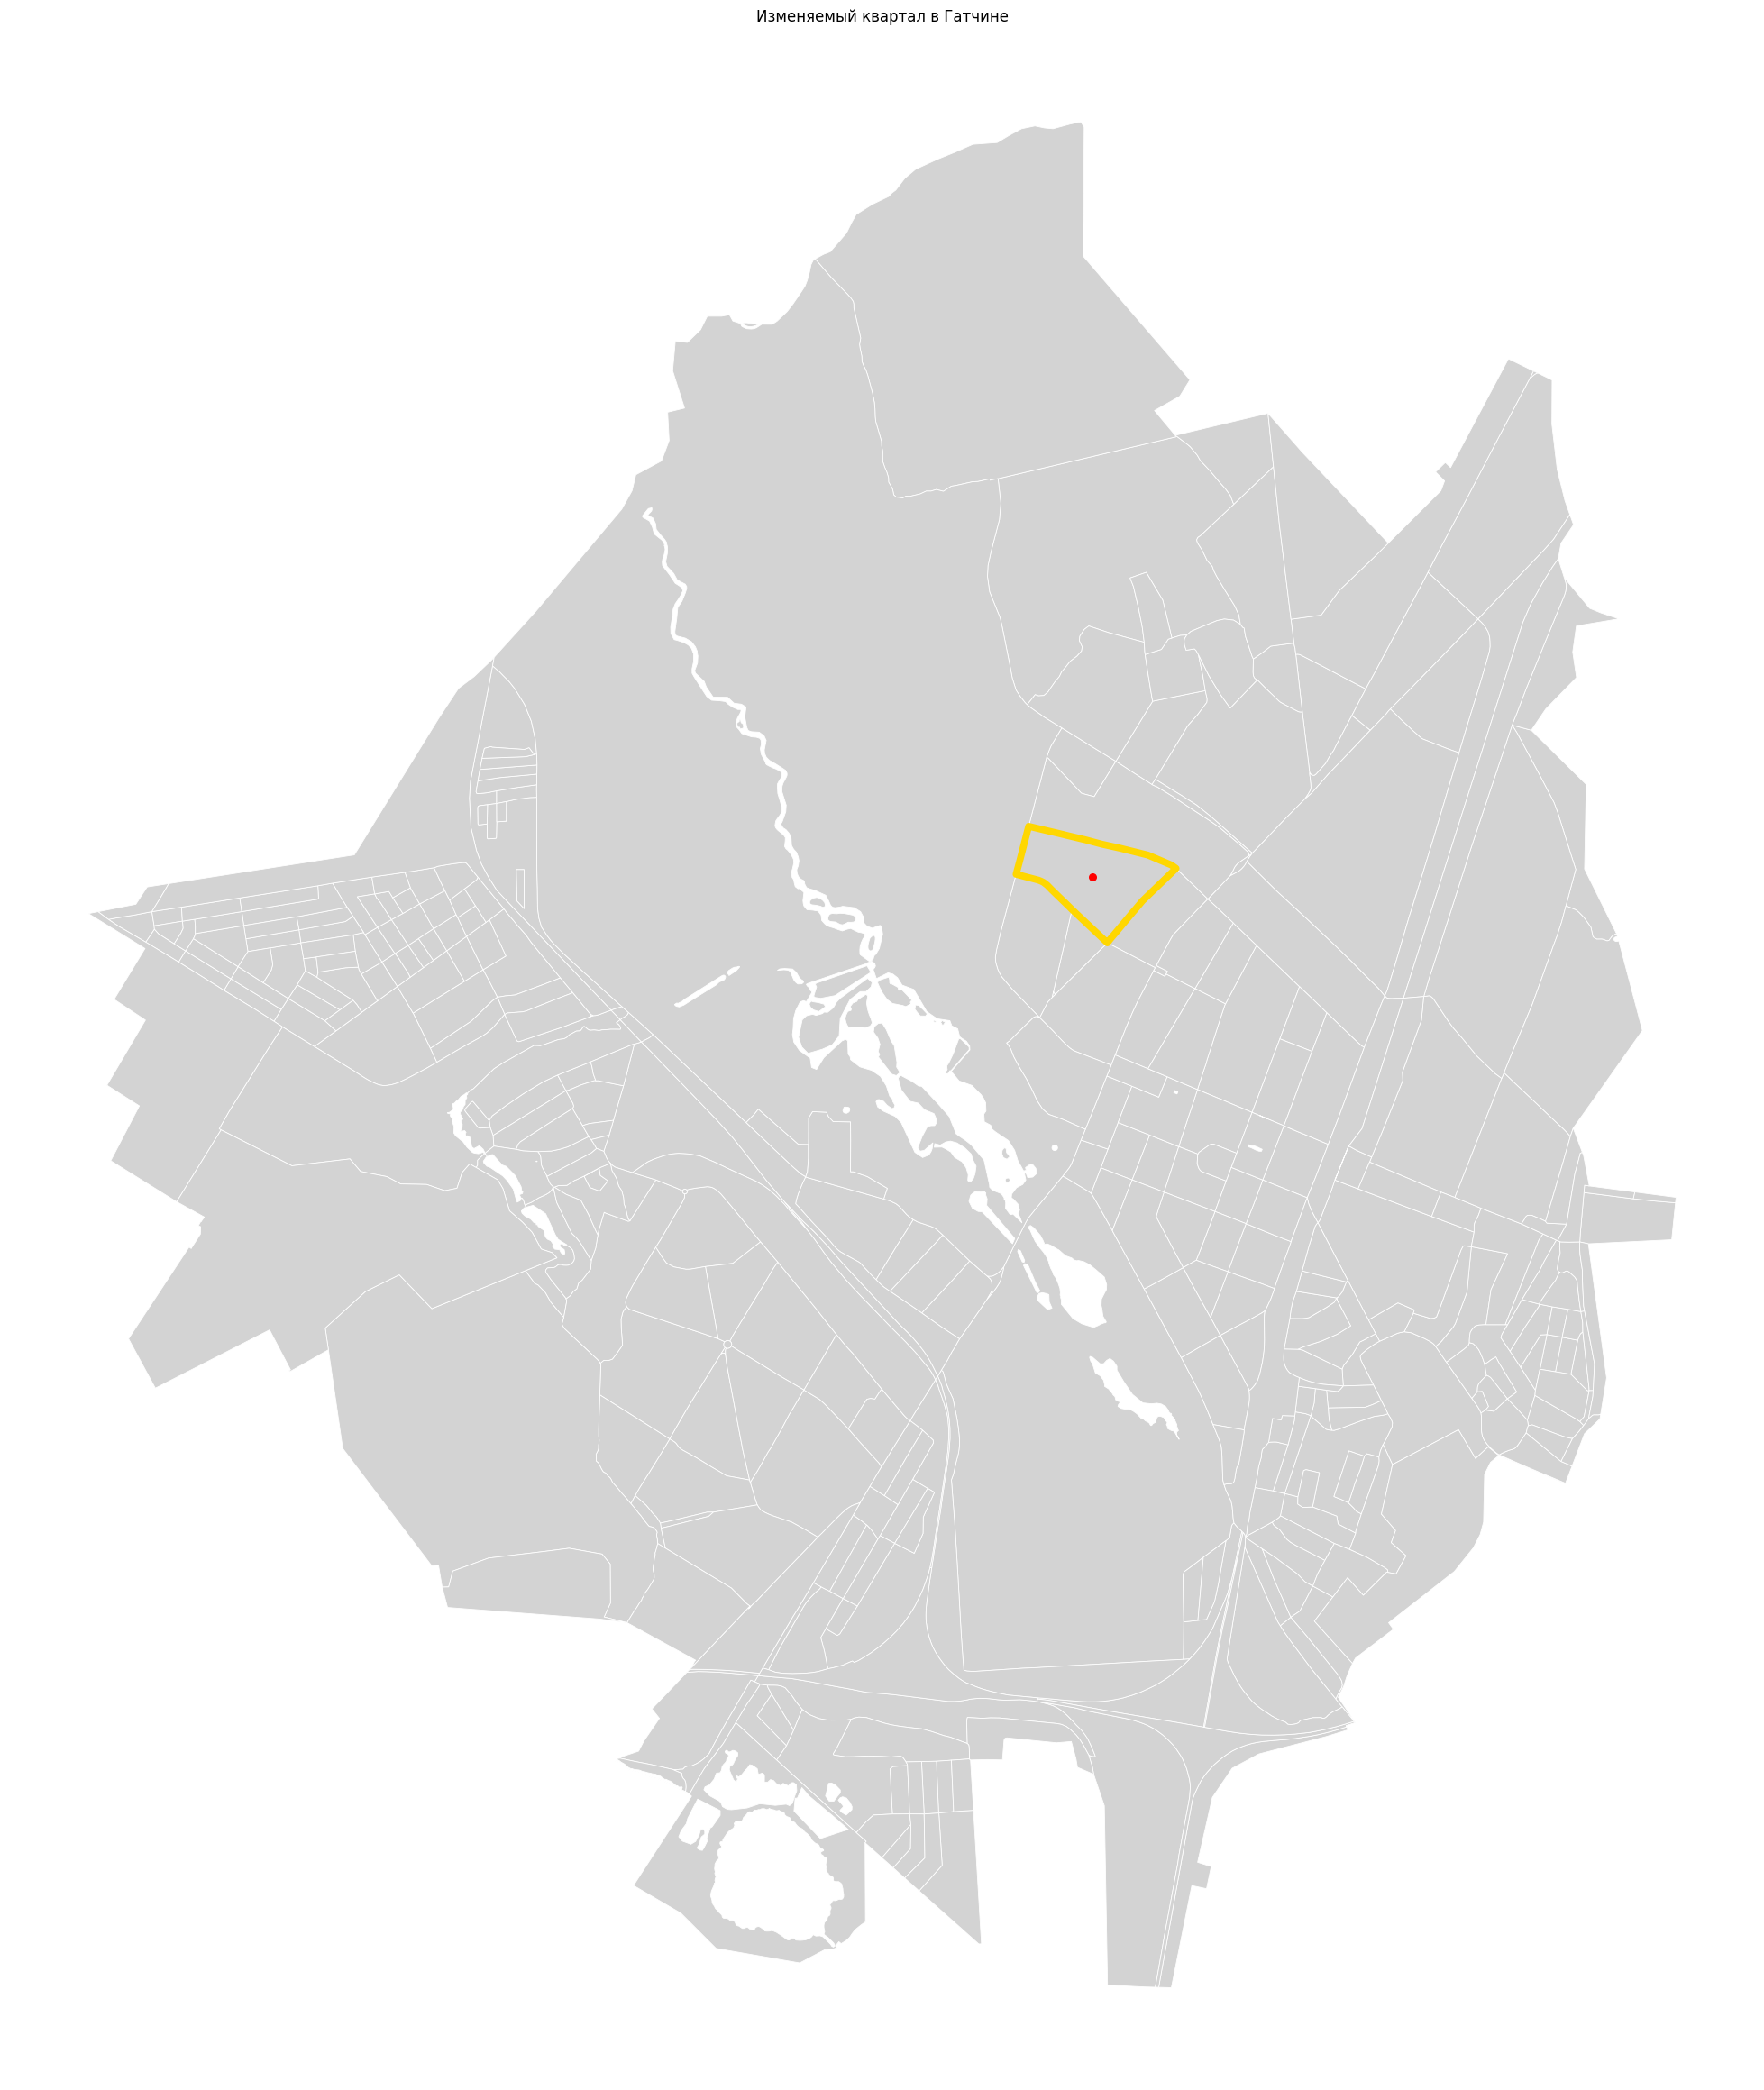

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)  # фон
blocks_clean.loc[blocks_clean["id"]==87].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=5.5
)
blocks_clean.loc[blocks_clean["id"]==87].centroid.plot(
     ax=ax, color="red", markersize=30, zorder=3
 )

ax.set_title("Изменяемый квартал в Гатчине")
ax.axis("off")
plt.show()

In [21]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

# Оптимизация агентами!

# **Инвестиционная** привлекактельтность 

In [66]:
target_idx = 87

In [67]:
blocks_after = basline_blocks.copy()
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_idx, "is_project"] = True


In [68]:
from blocksnet.enums import LandUse

benchmarks_ru = {
    LandUse.RESIDENTIAL: {
        "cost_build": 70_000,       # руб/м2 (жильё, СПб/ЛО)
        "price_sale": 160_000,      # руб/м2 (средний класс)
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 900,           # эксплуатация жилого фонда
    },
    LandUse.BUSINESS: {
        "cost_build": 85_000,       # офисно-деловая застройка
        "rent_annual": 28_000,      # руб/м2/год
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_400,
    },
    LandUse.RECREATION: {
        "cost_build": 40_000,       # парки, культура, спорт
        "rent_annual": 7_500,       # чаще косвенные доходы/аренда
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 650,
    },
    LandUse.SPECIAL: {              # образование/медицина, гос объект
        "cost_build": 55_000,
        "rent_annual": 12_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_700,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 45_000,       # промка (ангар, лайт-индастри)
        "rent_annual": 15_500,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 750,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 28_000,
        "rent_annual": 7_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 350,
    },
    LandUse.TRANSPORT: {
        "cost_build": 30_000,       # склад, логистика, хабы
        "rent_annual": 7_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 650,
    },
}

In [69]:
from urbanomy.methods.investment_potential import prepare_investment_input


potential_df = pd.read_csv("/Users/andreyfeduhin/Urbanomy-data/data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_after,
    project_potential = potential_df,
)

investment_input.head()

2026-03-12 13:24:51.650 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:444 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.RESIDENTIAL,NaN,0.0,705080.041579,132192.815395,58395.681287,190588.496682,0.690324,0.0


In [70]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_ru)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          705,080.04
 • Built area:         190,588.50
 • Land value:         0.00
 • Construction cost:  13,341,194,767.72
 • Investment need:    13,341,194,767.72
 • Spatial potential:  0.00
 • Project NPV:        2,987,412,620.24
 • Project IRR:        0.26
 • Project ROI:        4.70
 • Project PP (yrs):   5.93
 • Project EI:         84.96
 • Project INV score:  50.98


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,705080.04,0.0,190588.5,NaN,1.334119e+10,1.334119e+10,2.987413e+09,0.26,4.7,5.93,84.96,0.0,50.98


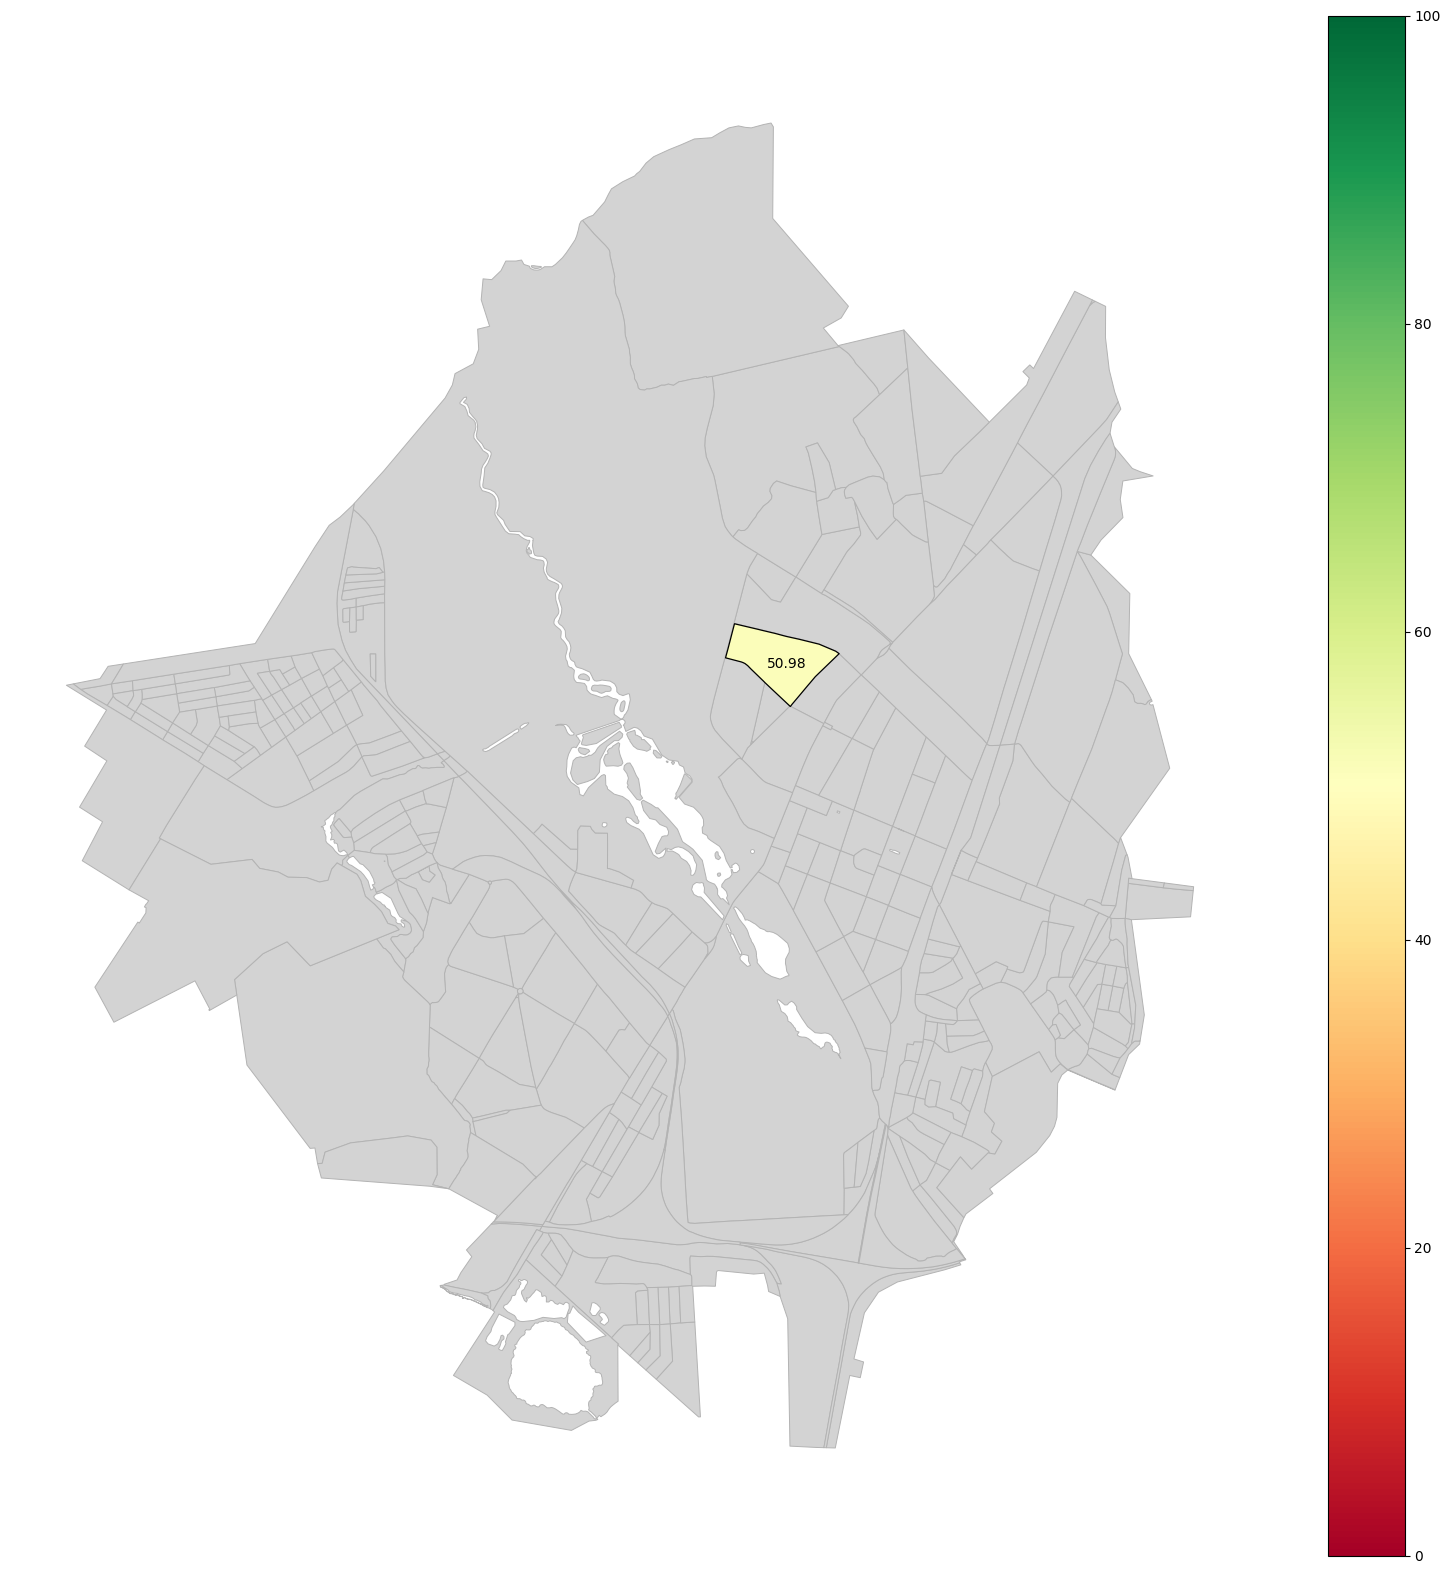

In [71]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "INV"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(20, 20))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [72]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,44 471
1,Валовый региональный продукт на душу населения,21 282
2,Доходы бюджета территории,5 569 948 816
3,Средний уровень заработной платы,0.0000
4,Износ основного фонда (тыс. руб.),380 224


In [73]:
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem
# теперь оптимизируем пустой район генетикой!
target_idx = 87
blocks_after.iloc[86]
site_area = float(blocks_after["site_area"].iloc[86])
floors_neighborhood_avg = blocks_after['build_floor_area'].mean() 


In [74]:
from urbanomy.methods.land_value_modeling.llm_agents import load_pdfs, PolicyRAGStore
docs = load_pdfs('/Users/andreyfeduhin/Downloads/Urbanomy/examples/land_value_modeling/pdf_docs')

In [75]:
from sentence_transformers import SentenceTransformer

# загружаем модель эмбеддингов
embedding_model = SentenceTransformer("intfloat/multilingual-e5-base")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [76]:
policy_rag = PolicyRAGStore(embedding_model)

policy_rag.add_documents(docs)

In [77]:
policy_rag.search(
    "максимальная этажность в гатчине",
    top_k=5
)

[{'text': 'благоустройству при условии сохранения ценных элементов планировочной и ландшафтно-композиционной структуры. б) вводятся следующие ограничения: - максимальная высота зданий, строений, сооружений на территории земельных участков: - жилой застройки – 10 м от красной отметки земли до конька; - нежилой застройки − 15 м от красной отметки земли. 7.',
  'meta': {'source': 'приложение_ПЗЗ_Гатчина_утв.pdf',
   'chunk_idx': 646,
   'chunk_count': 656,
   'length': 345},
  'score': 0.974723467435327},
 {'text': '- при изменении использования территории промышленных предприятий, расположенных вдоль ул. Михаила Рысева, необходимо проведение работ по озеленению и благоустройству при условии сохранения ценных элементов планировочной и ландшафтно- композиционной структуры. б) вводятся следующие ограничения: - минимальный отступ зданий, строений от линии застройки – 10 м. - максимальная высота зданий, строений, сооружений на территории земельных участков: - жилой застройки – 10 м от красной

In [78]:
problem = DistrictProblem(
    blocks=blocks_after,
    target_idx=target_idx,
    model=model,
    benchmarks=benchmarks_ru,
    potential_df=potential_df,
    constraints={
    # Площадь пятна застройки
    "footprint_area": {
        "type": "float",
        "min": 0.0,
        "max": 0.8 * site_area,
    },
# Площадь всех этажей
    "build_floor_area": {
        "type": "float",
        "min": 0,
        "max": floors_neighborhood_avg*2,
    },
# Жилая площадь
    "living_area": {
        "type": "float",
        "min": 0.0,
        "max": floors_neighborhood_avg*2,
    },
# land_use
    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business":    {"type": "float", "min": 0.0, "max": 1.0},
    "recreation":  {"type": "float", "min": 0.0, "max": 1.0},
    "industrial":  {"type": "float", "min": 0.0, "max": 1.0},
    "transport":   {"type": "float", "min": 0.0, "max": 1.0},
    "special":     {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
    },
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    }

)

In [79]:

from pymoo.algorithms.moo.nsga2 import NSGA2 # Импорт алгоритма
from pymoo.optimize import minimize 
algorithm = NSGA2(pop_size=20)
res = minimize(problem, algorithm, ('n_gen', 10), verbose=False) 


2026-03-12 13:25:52.109 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:444 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


Индивид 0: land_value = 83528990482.57
Project totals:
 • Land area:          705,080.04
 • Built area:         355,256.70
 • Land value:         0.00
 • Construction cost:  10,657,701,055.22
 • Investment need:    10,657,701,055.22
 • Spatial potential:  0.00
 • Project NPV:        -7,956,014,769.98
 • Project IRR:        -0.08
 • Project ROI:        -0.66
 • Project PP (yrs):   nan
 • Project EI:         0.00
 • Project INV score:  0.00


2026-03-12 13:25:52.809 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:444 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


Индивид 1: land_value = 78193416212.75
Project totals:
 • Land area:          705,080.04
 • Built area:         200,428.91
 • Land value:         0.00
 • Construction cost:  5,612,009,498.37
 • Investment need:    5,612,009,498.37
 • Spatial potential:  0.00
 • Project NPV:        -4,390,625,798.67
 • Project IRR:        -0.11
 • Project ROI:        -1.10
 • Project PP (yrs):   nan
 • Project EI:         0.00
 • Project INV score:  0.00


2026-03-12 13:25:53.685 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:444 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


...

Индивид 17: land_value = 81974538917.37
Project totals:
 • Land area:          705,080.04
 • Built area:         799,989.56
 • Land value:         0.00
 • Construction cost:  55,999,269,191.17
 • Investment need:    55,999,269,191.17
 • Spatial potential:  0.00
 • Project NPV:        12,539,575,834.01
 • Project IRR:        0.26
 • Project ROI:        4.70
 • Project PP (yrs):   5.93
 • Project EI:         84.96
 • Project INV score:  50.98


2026-03-12 13:28:17.799 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:444 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


Индивид 18: land_value = 81588681236.27
Project totals:
 • Land area:          705,080.04
 • Built area:         771,738.38
 • Land value:         0.00
 • Construction cost:  54,021,686,577.01
 • Investment need:    54,021,686,577.01
 • Spatial potential:  0.00
 • Project NPV:        12,096,747,784.35
 • Project IRR:        0.26
 • Project ROI:        4.70
 • Project PP (yrs):   5.93
 • Project EI:         84.96
 • Project INV score:  50.98


2026-03-12 13:28:18.520 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:444 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


Индивид 19: land_value = 81513581098.67
Project totals:
 • Land area:          705,080.04
 • Built area:         788,901.30
 • Land value:         0.00
 • Construction cost:  55,223,091,194.74
 • Investment need:    55,223,091,194.74
 • Spatial potential:  0.00
 • Project NPV:        12,365,771,014.99
 • Project IRR:        0.26
 • Project ROI:        4.70
 • Project PP (yrs):   5.93
 • Project EI:         84.96
 • Project INV score:  50.98


In [80]:
print("Лучшие решения (переменные):\n", res.X) # Массив решений на фронте Парето
print("Значения целевых функций:\n", -res.F)


Лучшие решения (переменные):
 [[8.11033001e+05 6.85738122e+03 9.27169568e+03 9.07199360e-01
  4.50719042e-01 2.82905123e-01 6.50140859e-01 5.67834058e-01
  2.78348457e-01 4.48629578e-02]
 [8.15565304e+05 4.95637340e+03 4.44425731e+03 6.94067756e-01
  4.62182893e-01 3.45486146e-01 4.73868355e-01 6.42810379e-01
  6.80166690e-02 4.83570546e-01]
 [8.01368033e+05 5.00369967e+03 9.52419124e+03 9.66375571e-01
  5.50903817e-01 3.45020730e-01 4.75127164e-01 5.83939129e-01
  1.89128205e-01 3.17145514e-02]
 [4.49414848e+05 6.85738122e+03 9.42528437e+03 8.96727604e-01
  4.09620458e-01 3.10931197e-01 6.50140859e-01 7.83271001e-01
  1.83720234e-01 1.81546424e-02]
 [8.10683520e+05 6.85738122e+03 9.38549766e+03 9.07199360e-01
  4.09620458e-01 2.82974274e-01 6.50140859e-01 6.02540493e-01
  1.83720234e-01 4.56837908e-02]
 [8.08699649e+05 6.80741120e+03 9.42674426e+03 9.13486519e-01
  4.89354292e-01 3.45486146e-01 6.52733031e-01 2.14111147e-01
  6.80166690e-02 2.06423765e-02]
 [8.00395022e+05 5.78865616e

In [81]:

from urbanomy.methods.land_value_modeling.llm_agents import OllamaLLM, CityAdministrationAgent, ResidentsAgent, InvestorsAgent, DeveloperAggregator,CityRAGBuilder, run_multiagent_loop, CityRAGStore,CityRAGBuilder

llm = OllamaLLM(model="llama3", temperature=0.7)

print(llm.generate("Скажи одним предложением, что такое город"))


Город - это большой населенный пункт, который является центром экономической, культурной и социальной жизни, характеризующийся концентрацией населения, инфраструктуры и услуг в определенной местности.


In [82]:
len(res.opt)

10

In [83]:
from sentence_transformers import SentenceTransformer

builder = CityRAGBuilder(blocks_after)
docs = builder.build_docs()

In [84]:
rag_store = CityRAGStore()
rag_store.add_documents(docs)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-l6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [85]:
agents = [
    CityAdministrationAgent("city", llm, rag_store),
    ResidentsAgent("residents", llm, rag_store),
    InvestorsAgent("investors", llm, rag_store),
]

In [86]:
agents[0].evaluate('привет')

"As the city administration, I will evaluate the proposed changes for each region based on the development of the city, sustainable development, compliance with the master plan, and public interests.\n\nRegion 153:\nThe proposal seems to be focused on business development, which is reflected in the low-rise non-residential morphotype. The area is characterized by a relatively large footprint and a small built-up area, indicating a potential for future growth. However, the lack of residential population (0 people) raises concerns about the sustainability of the zone. I would suggest reevaluating the master plan to ensure that this region aligns with the city's overall development goals.\n\nRegion 3:\nThe proposal appears to be centered on low-rise business and model developments, which is consistent with the existing morphotype. The area has a small footprint and built-up areas, indicating a relatively compact zone. The presence of a residential population (134 people) suggests that thi

In [87]:
for i, opt in enumerate(res.opt):
    params = {name: opt.X[j] for j, name in enumerate(problem.var_names)}
    params = problem._repair_genome(params)
   # plot_scenario_impact(
   #     blocks_before=blocks_after,
   #     blocks_after=ScenarioTEPModifier(blocks_after).apply(target_idx, params),
    #    orig_features=numeric_feats+cat_features,
   #     categorical_features=cat_features,
    #    model=model,
    #    target_idx=target_idx,
    #    figsize=(25, 35),
    #)
    for agent in agents:
        print(agent.evaluate(params))
    print(f"Решение {i}:")
    print("Переменные (геном):", opt.X)
    print("Целевые функции:", -opt.F)
    print("-" * 30)

As the representative of the city administration, I will assess the proposed changes for the development of this region.

Firstly, the existing land use parameters indicate a low-rise non-residential area with no residential population. The business and industrial areas are prominent, while recreational spaces and transportation infrastructure are relatively underdeveloped.

Considering the context of other regions (Rai 153, 3, and 4), I notice that this region has a higher footprint area and build floor area compared to those regions. This suggests that the existing development pattern in this region is more extensive and dense.

From my perspective, the proposed changes seem to align with the city's goals of sustainable development and balancing functions. The emphasis on business and industrial areas supports economic growth, while the presence of recreational spaces and transportation infrastructure will improve the quality of life for residents.

However, I would like to see a mor